In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## get 1 year of 5m NSW data
## cannot do here, need to create a script
df = pd.read_csv('../../data/NEM_NSW1_2025-01-01_2025-12-31_1h.csv')
df.head()
## create a stochastic dynamics model using the median reversion model from kim and powell


,timestamp,price
0,2025-01-01 10:00:00,124.35667
1,2025-01-01 11:00:00,109.70750
2,2025-01-01 12:00:00,104.36167
3,2025-01-01 13:00:00,103.73833
4,2025-01-01 14:00:00,102.45000


<Axes: >

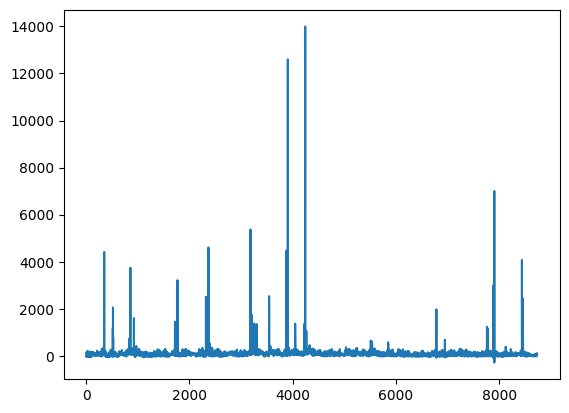

In [202]:
df.price.plot()

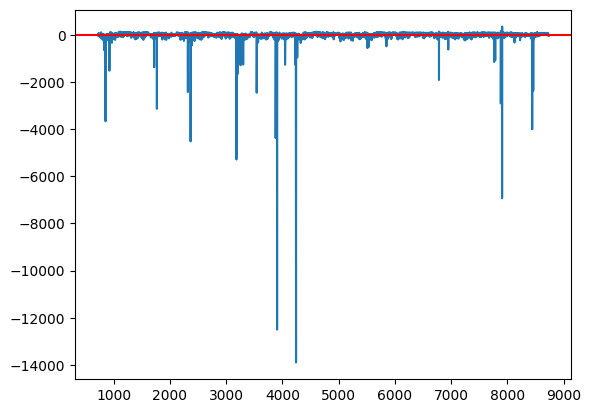

In [114]:
diff_to_med = (df.price.rolling(window=24*30).median() - df.price).dropna()
median_diff = np.median(diff_to_med.values)
plt.plot(diff_to_med)
plt.axhline(median_diff, c = 'red')
# plt.ylim(-300, 300)

In [109]:
median_diff

np.float64(0.0)

<Axes: >

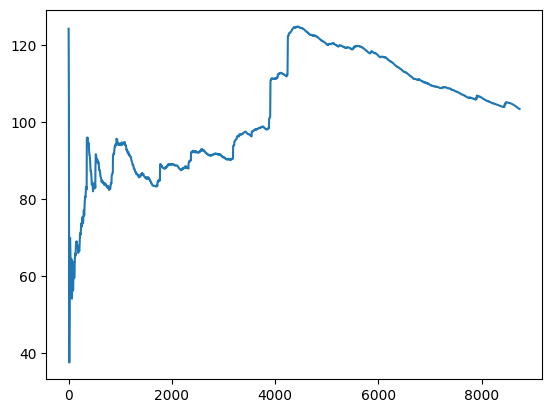

In [115]:
(df.price.cumsum() / np.arange(1, df.shape[0]+1)).plot()

In [249]:
from collections import deque
from scipy.stats import cauchy, iqr

class MedianReversionPriceModel:
    def __init__(self, interval='5m'):
        if interval == '5m':
            self.window_size = (60 // 5) * 24 * 30
        elif interval == '1h':
            self.window_size = 24 * 30
        else:
            raise NotImplementedError(f"{interval} not implemented")
        self._buffer: deque[float] = deque(maxlen=self.window_size)
        self.kappa = None
        self.loc = None
        self.scale = None

    @property
    def rolling_median(self) -> float:
        if not self._buffer:
            raise ValueError("No observations. Call fit() or update() first.")
        return float(np.median(self._buffer))

    @property
    def current_price(self) -> float:
        return self._buffer[-1]

    def fit(self, prices: pd.Series):
        rolling_med = prices.rolling(window=self.window_size).median().shift(1)
        prev_prices = prices.shift(1)
        denominator = rolling_med - prev_prices
        numerator = prices - prev_prices
        Y = (numerator / (denominator + 1.0e-6)).dropna()

        errors = Y / np.median(Y)
        self.kappa = 1 - np.median(Y)
        self.loc = 1.0
        self.scale = iqr(errors) / 2

        # seed buffer with last window_size prices
        for p in prices.values[-self.window_size:]:
            self._buffer.append(float(p))
        
        clean_prices = prev_prices[rolling_med.notna()]
        clean_rolling_med = rolling_med.dropna()
        assert clean_prices.shape[0] == clean_rolling_med.shape[0]
        self.predictions = [
            self.predict_price_distribution(clean_prices.values[i], clean_rolling_med.values[i])
            for i in range(clean_prices.shape[0])
        ]
    
    def predict_price_distribution(self, prices: float, rolling_med: float):
        """
        Transform error distribution to price distribution.
        """
        return cauchy(
            loc = self.predict_price_location(prices, rolling_med),
            scale = self.predict_price_scale(prices, rolling_med)
        )

    def predict_price_location(self, prices: float, rolling_med: float):
        """
        Transform location from error dist to prices
        """
        return prices + (1 - self.kappa) * (rolling_med - prices) * self.loc
    
    def predict_price_scale(self, prices: float, rolling_med: float):
        """
        Transform scale from error dist to prices
        """
        return abs((1 - self.kappa) * (rolling_med - prices)) * self.scale

    def update(self, new_price: float):
        """Roll forward one observation. Updates the rolling median buffer."""
        self._buffer.append(new_price)

    def predict(self, horizon: int) -> list:
        """Return a list of frozen Cauchy distributions, one per step ahead.

        Each distribution can be:
          - sampled:   dist.rvs(size=1000)
          - quantiled: dist.ppf([0.025, 0.5, 0.975])
          - pdf/cdf:   dist.pdf(x), dist.cdf(x)
          - stats:     dist.median(), dist.mean() (Cauchy mean is undefined)
        """
        p = self.current_price
        mu = self.rolling_median
        dists = []
        for h in range(1, horizon + 1):
            reversion = 1 - self.kappa ** h
            loc = p + reversion * (mu - p)
            scale = abs(reversion * (mu - p)) * self.scale
            dists.append(cauchy(loc=loc, scale=scale))
        return dists


model = MedianReversionPriceModel(interval='1h')
model.fit(prices=df.price)

# predict returns frozen distributions
dists = model.predict(horizon=12)
print(f"Type: {type(dists[0])}")
print(f"Median forecast h=1: {dists[0].ppf(0.5):.2f}")
print(f"90% interval h=1: [{dists[0].ppf(0.05):.2f}, {dists[0].ppf(0.95):.2f}]")
print(f"Samples h=1: {dists[0].rvs(size=5)}")

Type: <class 'scipy.stats._distn_infrastructure.rv_continuous_frozen'>
Median forecast h=1: 104.30
90% interval h=1: [1.68, 206.91]
Samples h=1: [113.62170383 119.44579244  62.8643829   89.74084662 105.62954417]


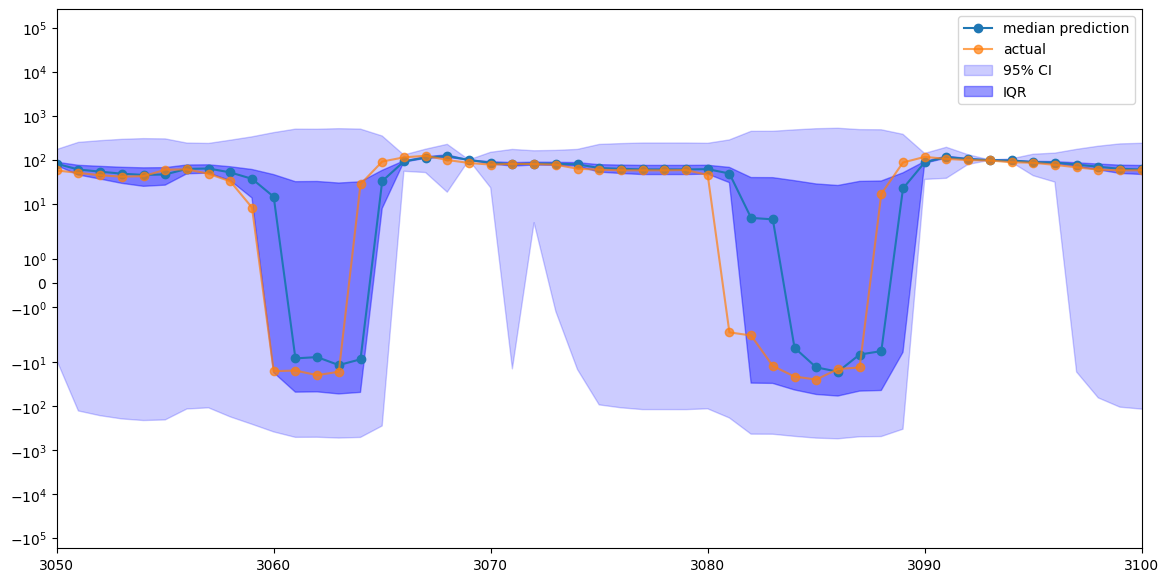

In [250]:
train_dists = model.predictions
quantiles = [0.025, 0.25, 0.5, 0.75, 0.975]
preds = np.array([d.ppf(quantiles) for d in train_dists]) 

x = np.arange(1, len(train_dists) + 1)
actual = df.iloc[720:].price.values

plt.subplots(figsize = (14, 7))
plt.plot(x, preds[:, 2], label='median prediction', marker='o')
plt.plot(x, actual, label='actual', marker='o', alpha = 0.7)
plt.fill_between(x, preds[:, 0], preds[:, 4], color='blue', alpha=0.2, label='95% CI')
plt.fill_between(x, preds[:, 1], preds[:, 3], color='blue', alpha=0.4, label='IQR')
plt.legend()
plt.yscale('symlog')
# plt.ylim(-100, 100)
plt.xlim(3050, 3100)
plt.show()

In [254]:
np.median(df.price.values), model.rolling_median

(np.float64(79.847917), 57.7370835)

In [255]:
cauchy_error_dist = cauchy(loc = model.loc, scale = model.scale)
kappa = model.kappa
num_steps = 24 # try one day
price = 57
sampled_prices = np.zeros((num_steps,))
for n in range(num_steps):
    monthly_median = model.rolling_median
    error = cauchy_error_dist.rvs()
    price = price + (1 - kappa) * (monthly_median - price) * error
    sampled_prices[n] = price
    model.update(price)


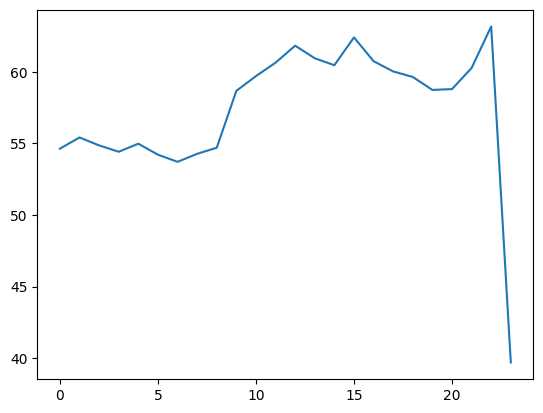

In [256]:
plt.plot(sampled_prices)

In [221]:
cauchy_error_dist.rvs()

np.float64(0.06679829469978682)

In [209]:
in_iqr = (((actual > preds[:,1]) & (actual < preds[:, 3]))*1).sum() / actual.shape[0]
in_95 = (((actual > preds[:,0]) & (actual < preds[:, 4]))*1).sum() / actual.shape[0]
print(in_iqr, in_95)

0.4943862275449102 0.93687624750499


In [213]:
from battery_sim.agents.agent import BatteryAgent
from battery_sim.agents.policies.rule_based import ThresholdPolicy
from battery_sim.battery.battery import Battery
from battery_sim.models.naive import PersistenceModel
from battery_sim.simulation.env import SimulationEnv

battery = Battery(
    capacity_mwh=2.0,
    max_charge_rate_mw = 1.0,
    max_discharge_rate_mw=1.0,
    efficiency=0.9
)
policy = ThresholdPolicy(
    charge_below=0.0,
    discharge_above=120.0,
    charge_rate=1.0,
    discharge_rate=1.0,
)

agent = BatteryAgent(policy=policy)
env = SimulationEnv(battery=battery, price_data=df, interval_minutes=60)

In [214]:
def run_simulation(
        agent: BatteryAgent,
        env: SimulationEnv
    ):

    obs = env.reset()
    done = False

    while not done:
        action = agent.act(obs)
        next_obs, reward, done = env.step(action)
        agent.update(obs, action, reward, next_obs, done)
        obs = next_obs
    
run_simulation(agent = agent, env = env)

result = env.get_result()
print(f"Total steps: {result.total_steps}")
print(f"Cumulative revenue: ${result.cumulative_revenue:.2f}")

Total steps: 8736
Cumulative revenue: $76563.22


In [210]:
print(
    np.quantile(df.price.values, quantiles)
)

[-25.840417    42.7208335   79.847917   119.875      260.23291875]


## Probabilistic Threshold Policy

In [3]:
from battery_sim.agents.policies.probabilistic import ProbabilisticThresholdPolicy
from battery_sim.models.median_reversion import MedianReversionModel

# Split data into train/test
split = int(len(df) * 0.7)
train_df = df.iloc[:split].reset_index(drop=True)
test_df = df.iloc[split:].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")

Train: 6115 rows, Test: 2621 rows


In [6]:
from battery_sim.battery.battery import Battery
# Create model and policy
price_model = MedianReversionModel(window_days=30, interval_minutes=60)

prob_policy = ProbabilisticThresholdPolicy(
    model=price_model,
    buy_threshold=50.0,
    sell_threshold=200.0,
    charge_rate=1.0,
    discharge_rate=1.0,
)

battery = Battery(
    capacity_mwh=2.0,
    max_charge_rate_mw = 1.0,
    max_discharge_rate_mw=1.0,
    efficiency=0.9
)

# Learn: fits model on train data, then grid searches buy/sell thresholds
prob_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24 * 7,  # 1 week windows at 1h interval
)

print(f"Learned buy_threshold: {prob_policy.buy_threshold}")
print(f"Learned sell_threshold: {prob_policy.sell_threshold}")

c:\Users\61417\Documents\misc_projects\battery_charging_simulation\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\61417\Documents\misc_projects\battery_charging_simulation\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\61417\Documents\misc_projects\battery_charging_simulation\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2159: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
c:\Users\61417\Documents\misc_projects\battery_charging_simulation\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\61417\Documents\misc_projects\battery_charging_simulation\.venv\Lib\site-packages\scipy\stats\_

Learned buy_threshold: 50
Learned sell_threshold: 150


In [14]:
from battery_sim.agents.agent import BatteryAgent
from battery_sim.simulation.env import SimulationEnv
from battery_sim.agents.policies.rule_based import ThresholdPolicy
# Evaluate on test set using run_simulation
prob_agent = BatteryAgent(policy=prob_policy)
test_env = SimulationEnv(battery=battery, price_data=test_df, interval_minutes=60)

run_simulation(agent=prob_agent, env=test_env)
prob_result = test_env.get_result()
print(f"Probabilistic policy - Test revenue: ${prob_result.cumulative_revenue:.2f}")

# Compare with the deterministic threshold policy
det_policy = ThresholdPolicy(charge_below=50, discharge_above=150.0, charge_rate=1.0, discharge_rate=1.0)
det_agent = BatteryAgent(policy=det_policy)
det_env = SimulationEnv(battery=battery, price_data=test_df, interval_minutes=60)

run_simulation(agent=det_agent, env=det_env)
det_result = det_env.get_result()
print(f"Deterministic policy  - Test revenue: ${det_result.cumulative_revenue:.2f}")

Probabilistic policy - Test revenue: $35230.87
Deterministic policy  - Test revenue: $32301.22


In [ ]:
from battery_sim.optimization.policy_optimizer import evaluate_policy

evaluate_policy(
    policy = 
)

AttributeError: 'SimResult' object has no attribute 'to_dataframe'